# 실습 — YOLO 객체 탐지 (11주차 부록 / JupyterLab)

> **부록 B의 실습 노트북**입니다. 이론은 [`../../11_week/plane/부록B_YOLO_객체탐지_이론과실습.md`] 참고.

**학습 목표**
- 울트라리틱스(`ultralytics`) YOLO 모델을 1줄로 로드한다.
- **내 이미지를 JupyterLab에 추가**하고 객체 탐지를 실행한다.
- 탐지 결과(경계 상자·라벨·확신도)를 그림과 표로 읽는다.

**핵심 흐름**: `YOLO("yolov8n.pt")` → `detect_and_show("내사진.jpg")` → 상자·라벨 확인

---

## 📂 JupyterLab에 내 이미지를 추가하는 방법 (3가지)

이 노트북은 `BigDataAnalysis/11_week/` 폴더에서 열려 있다고 가정합니다.

**방법 1 — 드래그 앤 드롭 (가장 쉬움) ★**
```
1. JupyterLab 왼쪽의 [파일 탐색기] 패널을 본다.
2. 11_week 폴더(또는 sample_images 폴더)가 열려 있는지 확인.
3. 내 컴퓨터의 사진 파일을 패널 안으로 그냥 끌어다 놓는다(드래그&드롭).
4. 업로드된 파일명을 확인한다. 예: my_photo.jpg
```

**방법 2 — 업로드 버튼**
```
파일 탐색기 상단의 ⬆(Upload) 버튼 클릭 → 사진 선택
```

**방법 3 — 노트북 안 업로드 위젯** (맨 아래 셀 [6] 참고)

> 업로드한 파일명을 셀 [4]의 `my_image` 변수에 적으면 끝입니다.


## 셀 [0] — 설치 확인 + 공통 import

처음 한 번만 `ultralytics`를 설치합니다. 이미 설치돼 있으면 그냥 넘어갑니다.

In [1]:
# ultralytics가 없으면 설치 (노트북 안에서 직접 설치 가능)
try:
    import ultralytics  # noqa: F401
    print("✅ ultralytics 이미 설치됨")
except ImportError:
    print("⏳ ultralytics 설치 중... (1~2분)")
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics"], check=True)
    print("✅ 설치 완료")

# 한글 폰트 설정 (1~3교시와 동일)
import platform
import matplotlib.pyplot as plt
from matplotlib import rcParams

if platform.system() == "Windows":
    rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    rcParams["font.family"] = "AppleGothic"
rcParams["axes.unicode_minus"] = False
print("✅ 한글 폰트 설정 완료")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\6-112\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ ultralytics 이미 설치됨
✅ 한글 폰트 설정 완료


## 셀 [1] — YOLO 모델 로드

첫 실행 시 `yolov8n.pt`(약 6MB)가 자동 다운로드됩니다. nano 모델이라 **CPU에서도 빠릅니다.**

In [2]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")     # n = nano: 가장 작고 빠른 모델

print("✅ YOLO 모델 로드 완료")
print("이 모델이 알아보는 물체 종류 수:", len(model.names), "종 (COCO 데이터셋)")
print("예시 종류:", [model.names[i] for i in range(10)])

✅ YOLO 모델 로드 완료
이 모델이 알아보는 물체 종류 수: 80 종 (COCO 데이터셋)
예시 종류: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


## 셀 [2] — 탐지 + 시각화 함수 만들기

이미지 경로 하나만 주면 **상자 그리기 + 결과 요약**까지 해주는 함수입니다.
앞으로는 `detect_and_show("사진경로")` 한 줄이면 됩니다.

In [3]:
import os
from collections import Counter

def detect_and_show(image_path, conf=0.25):
    """이미지 경로(또는 URL)를 받아 YOLO 탐지 후 결과를 그림+표로 보여준다.

    image_path : 탐지할 이미지 경로(파일) 또는 웹 URL
    conf       : 확신도 문턱값(0~1). 낮추면 더 많이, 높이면 확실한 것만.
    """
    # 파일이 없으면 샘플로 대체 (URL은 그대로 통과)
    if not str(image_path).startswith("http") and not os.path.exists(image_path):
        print(f"⚠️ '{image_path}' 를 찾을 수 없어 sample_images/dog.jpg 로 대체합니다.")
        image_path = "sample_images/dog.jpg"

    results = model(image_path, conf=conf, verbose=False)
    r = results[0]

    # 1) 상자가 그려진 이미지 보여주기
    annotated_rgb = r.plot()[:, :, ::-1]   # plot()은 BGR → RGB로 뒤집기
    plt.figure(figsize=(9, 7))
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.title(f"YOLO 탐지 결과 — 물체 {len(r.boxes)}개 (conf ≥ {conf})")
    plt.show()

    # 2) 결과 요약 (종류별 개수)
    if len(r.boxes) == 0:
        print("탐지된 물체가 없습니다. conf 값을 낮춰보세요 (예: detect_and_show(경로, conf=0.1)).")
    else:
        names = [model.names[int(c)] for c in r.boxes.cls]
        print("🔍 찾은 물체:")
        for name, n in Counter(names).most_common():
            print(f"   - {name}: {n}개")
    return results

print("✅ detect_and_show() 함수 준비 완료")

✅ detect_and_show() 함수 준비 완료


## 셀 [3] — 먼저 샘플 이미지로 테스트

내 사진을 넣기 전에, 11주차 `sample_images/` 폴더의 강아지 사진으로 잘 동작하는지 확인합니다.

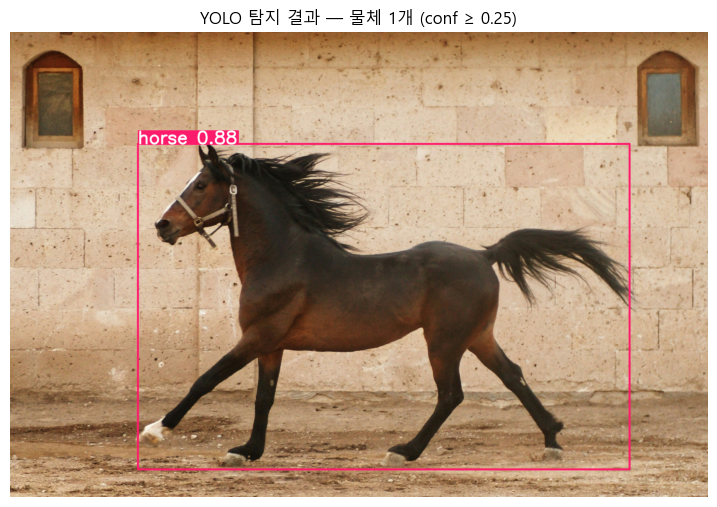

🔍 찾은 물체:
   - horse: 1개


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [5]:
detect_and_show("sample_images/selcuk-ulutas-CbnogotK6P8-unsplash.jpg")

## 셀 [4] — 내 이미지로 탐지하기 ★ (오늘의 핵심)

위 [📂 추가하는 방법]대로 JupyterLab에 사진을 끌어다 놓은 뒤,
아래 `my_image` 에 **그 파일명**을 적고 실행하세요.

- 사진을 `11_week/` 폴더에 넣었다면 → `"my_photo.jpg"`
- `sample_images/` 폴더에 넣었다면 → `"sample_images/my_photo.jpg"`

> 파일을 아직 안 넣었으면 자동으로 샘플 이미지로 대체 실행됩니다.

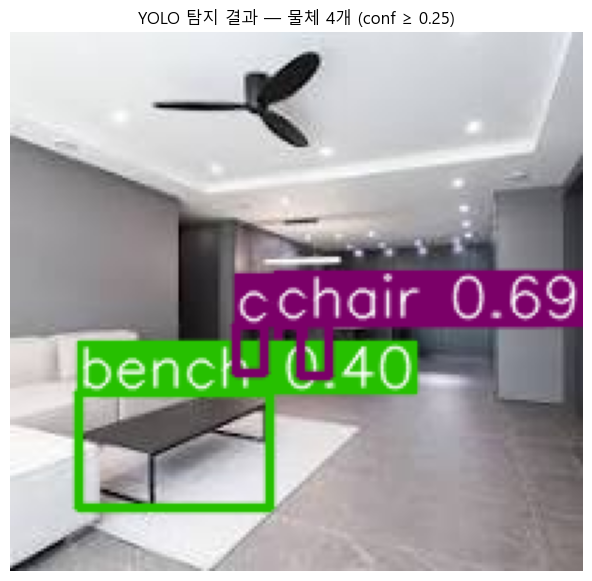

🔍 찾은 물체:
   - chair: 3개
   - bench: 1개


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [5]:
# TODO: JupyterLab에 추가한 본인 사진 파일명으로 바꾸세요
my_image = "sample_images/house.jpg"

detect_and_show(my_image)

## 셀 [5] — 결과를 표로 자세히 읽기

그림만 보지 말고, 데이터 과학자처럼 **상자 좌표·확신도**까지 표로 읽어봅시다.

In [6]:
results = model("sample_images/dog.jpg", verbose=False)
r = results[0]

print(f"{'번호':>3} | {'라벨':<12} | {'확신도':>6} | 상자 좌표 (x1, y1, x2, y2)")
print("-" * 62)
for i, box in enumerate(r.boxes):
    cls_id = int(box.cls[0])
    label  = model.names[cls_id]
    conf   = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    print(f"{i:>3} | {label:<12} | {conf*100:5.1f}% | "
          f"({x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f})")

 번호 | 라벨           |    확신도 | 상자 좌표 (x1, y1, x2, y2)
--------------------------------------------------------------
  0 | dog          |  83.1% | (46, 8, 301, 217)


## 셀 [6] — (선택) 노트북 안에서 바로 업로드하기

드래그&드롭 대신 **노트북 위젯**으로 업로드할 수도 있습니다.
아래 셀을 실행하면 [Upload] 버튼이 나옵니다. 사진을 선택한 뒤 **다음 셀**을 실행하세요.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

uploader = widgets.FileUpload(accept="image/*", multiple=False)
display(uploader)
print("⬆ 위 버튼으로 이미지를 선택한 뒤, 아래 셀을 실행하세요.")

In [ ]:
# 업로드한 이미지를 저장하고 바로 탐지
if uploader.value:
    # ipywidgets 8.x은 tuple, 7.x은 dict 형태
    items = uploader.value if isinstance(uploader.value, (list, tuple)) else uploader.value.values()
    for item in items:
        fname = item["name"]
        with open(fname, "wb") as f:
            f.write(item["content"])
        print(f"✅ 저장됨: {fname}")
        detect_and_show(fname)
else:
    print("위 셀의 위젯에서 이미지를 먼저 업로드하세요.")

## 셀 [7] — 확신도 문턱값(conf) 조절

상자가 너무 많이/적게 나올 때 `conf` 로 조절합니다.
- `conf` 높임(0.5) → 확실한 것만, 상자 적음
- `conf` 낮춤(0.1) → 애매한 것도, 상자 많음(오탐 ↑)

In [ ]:
url = "https://ultralytics.com/images/bus.jpg"   # 사람·버스가 많은 예시 사진

print("[conf=0.5] 확실한 것만")
detect_and_show(url, conf=0.5)

print("\n[conf=0.1] 애매한 것까지")
detect_and_show(url, conf=0.1)

---
## 마무리 체크리스트

- [ ] 셀 [1]에서 YOLO 모델을 1줄로 로드했다.
- [ ] 셀 [3]에서 샘플 이미지로 탐지가 동작함을 확인했다.
- [ ] 셀 [4]에서 **내 사진**을 JupyterLab에 추가해 탐지했다.
- [ ] 셀 [5]에서 상자 좌표·확신도를 표로 읽었다.
- [ ] 셀 [7]에서 conf 값에 따라 상자 수가 달라짐을 확인했다.

## 미니 과제 — "우리 동네 YOLO 탐정"
1. 본인 사진 5장 이상(단체사진·길거리·책상 위·반려동물 등)을 추가해 탐지
2. **정확히 센 사진 2개** + **틀리거나 놓친 사진 2개** 정리
3. 틀린 사진에 대해 "왜 틀렸을까?" 2~3줄 (물체가 작음 / 80종에 없음 / 가려짐 등)
4. 소감: 분류(ViT)와 탐지(YOLO)를 모두 써본 느낌 5줄 이상

> **참고**: YOLO 기본 모델은 COCO 80종(사람·자동차·강아지·의자·컵 등)만 압니다.
> 김밥·우리 학교 마스코트 같은 새 물체는 12주차 **파인튜닝**으로 가르칠 수 있습니다.
